In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


⏳ Loading Completed Trips Audit data...
✅ Auditing 123 completed missions.


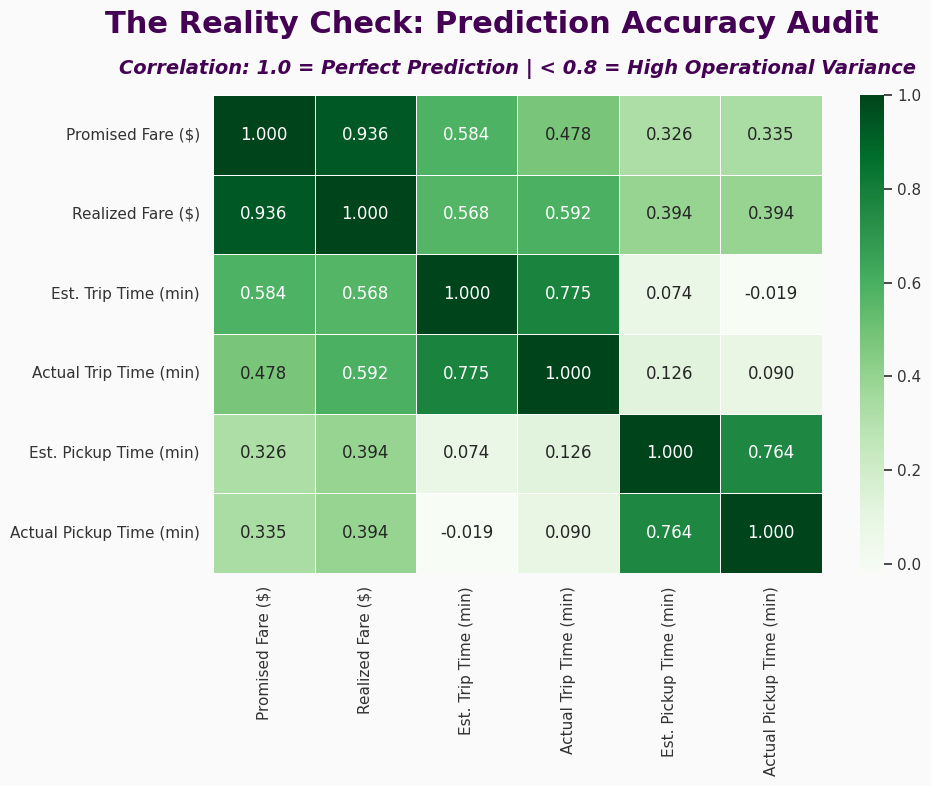

📊 Financial Correlation (Fare): 0.936
📊 Operational Correlation (Time): 0.775

Conclusion: The significant drop in correlation from Fare to Time justifies
the existence of the 'Fraud Prevention Mechanism'.


In [ ]:
# ==============================================================================
# CELL 1: THE REALITY CHECK MATRIX (PROMISE VS. EXECUTION)
# ==============================================================================
# Purpose: To audit the accuracy of the platform's predictions.
#          This serves as the empirical foundation for the
#          "Fraud Prevention Mechanism" hypothesis.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. LOAD DATA (JOINING PROMISE AND REALITY)
print("⏳ Loading Completed Trips Audit data...")
# We join 'offers' (Promise) with 'v_mission_dossier' (Reality)
query_reality = """
SELECT
    -- FINANCIALS
    o.upfront_fare              AS "Promised Fare ($)",
    kpi.realized_fare           AS "Realized Fare ($)",

    -- TRIP DURATION
    (o.est_trip_time_sec / 60.0)  AS "Est. Trip Time (min)",
    (kpi.duration_trip_sec / 60.0) AS "Actual Trip Time (min)",

    -- PICKUP FRICTION
    (o.time_to_pickup_sec / 60.0) AS "Est. Pickup Time (min)",
    (kpi.duration_to_pickup_sec / 60.0) AS "Actual Pickup Time (min)"

FROM v_mission_dossier kpi
JOIN offers o ON kpi.offer_id = o.offer_id
WHERE o.upfront_fare IS NOT NULL
  AND kpi.realized_fare IS NOT NULL
"""
df_reality_matrix = pd.read_sql(query_reality, db_engine).dropna()

print(f"✅ Auditing {len(df_reality_matrix)} completed missions.")

# 2. CALCULATE CORRELATION
corr_matrix_real = df_reality_matrix.corr(method='pearson')

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('The Reality Check: Prediction Accuracy Audit',
             fontsize=22, color=OPUS_PURPLE, weight='bold', y=0.98)

# 4. HEATMAP
# We highlight the disparity between Price Stability and Time Variance
sns.heatmap(
    corr_matrix_real,
    annot=True,
    fmt=".3f",
    cmap='Greens',
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title("Correlation: 1.0 = Perfect Prediction | < 0.8 = High Operational Variance",
             fontsize=14, style='italic', pad=15)

plt.tight_layout()
plt.show()

# Quick Insight Output
print(f"📊 Financial Correlation (Fare): {corr_matrix_real.iloc[0,1]:.3f}")
print(f"📊 Operational Correlation (Time): {corr_matrix_real.iloc[2,3]:.3f}")
print("\nConclusion: The significant drop in correlation from Fare to Time justifies")
print("the existence of the 'Fraud Prevention Mechanism'.")

In [ ]:
# ==============================================================================
# CELL 1: THE FORENSIC DATASET (DOUBLE SPREAD EXTRACTION)
# ==============================================================================
# Purpose: Extract the reconciled cohort of completed missions to analyze
#          the gap between the platform's promise and operational reality.
# ==============================================================================

# 1. THE SQL QUERY (Ratified Version)
query_double_spread = """
SELECT
    -- Identifiers
    v.offer_id,
    v.trip_id_legacy,

    -- 1. THE MONEY (Financial Spread)
    v.upfront_fare,
    v.realized_fare,
    ROUND(v.spread_percentage, 2) AS financial_spread,

    -- 2. THE TIME (Operational Delta)
    ROUND(o.est_trip_time_sec / 60.0, 2) AS est_time_min,
    ROUND(v.duration_trip_sec / 60.0, 2) AS actual_time_min,

    -- Delta in Minutes (Actual - Est)
    ROUND((v.duration_trip_sec - o.est_trip_time_sec) / 60.0, 2) AS delta_time_min,

    -- 3. THE TIME SPREAD (Operational Uncertainty)
    -- 1.00 = On Time | >1.00 = Slower | <1.00 = Faster
    ROUND(v.duration_trip_sec / o.est_trip_time_sec, 2) AS time_spread

FROM
    v_mission_dossier v
JOIN
    offers o ON v.offer_id = o.offer_id

WHERE o.est_trip_time_sec > 0
  AND v.realized_fare IS NOT NULL

ORDER BY (v.duration_trip_sec / o.est_trip_time_sec) DESC;
"""

# 2. EXECUTION
print("⏳ Executing Double Spread Extraction...")
df_risk = pd.read_sql(query_double_spread, db_engine)

# 3. BASIC AUDIT
print(f"✅ Extraction Successful: {len(df_risk)} missions loaded.")
print("\n--- SAMPLE: THE DISPARITY LEADERS ---")
display(df_risk.head(10))

# 4. QUICK DESCRIPTIVE STATS (Sanity Check)
print("\n--- OPERATIONAL SPREAD SUMMARY ---")
print(df_risk[['financial_spread', 'time_spread']].describe().T)

⏳ Executing Double Spread Extraction...
✅ Extraction Successful: 236 missions loaded.

--- SAMPLE: THE DISPARITY LEADERS ---


,offer_id,trip_id_legacy,upfront_fare,realized_fare,financial_spread,est_time_min,actual_time_min,delta_time_min,time_spread
0,OF03922,250925-04,174.94,211.79,1.21,20.0,48.12,28.12,2.41
1,OF00338,250825-03,292.43,305.71,1.05,25.0,54.07,29.07,2.16
2,OF03609,250923-05,148.69,184.73,1.24,23.0,46.58,23.58,2.03
3,OF01169,250901-04,101.43,83.26,0.82,10.0,19.98,9.98,2.00
4,OF00897,250828-07,112.94,139.44,1.23,20.0,38.78,18.78,1.94
5,OF01469,250903-03,176.14,150.38,0.85,11.0,20.72,9.72,1.88
6,OF01058,250829-06,184.28,205.0,1.11,34.0,61.02,27.02,1.79
7,OF02597,250917-08,122.44,148.77,1.22,33.0,58.25,25.25,1.77
8,OF01167,250901-03,104.04,83.84,0.81,12.0,20.67,8.67,1.72
9,OF04397,250929-09,162.84,194.62,1.20,39.0,67.07,28.07,1.72



--- OPERATIONAL SPREAD SUMMARY ---
                  count      mean       std   min   25%   50%   75%   max
financial_spread  236.0  0.836441  0.085840  0.70  0.77  0.82  0.88  1.24
time_spread       236.0  0.991568  0.279272  0.49  0.83  0.94  1.07  2.41


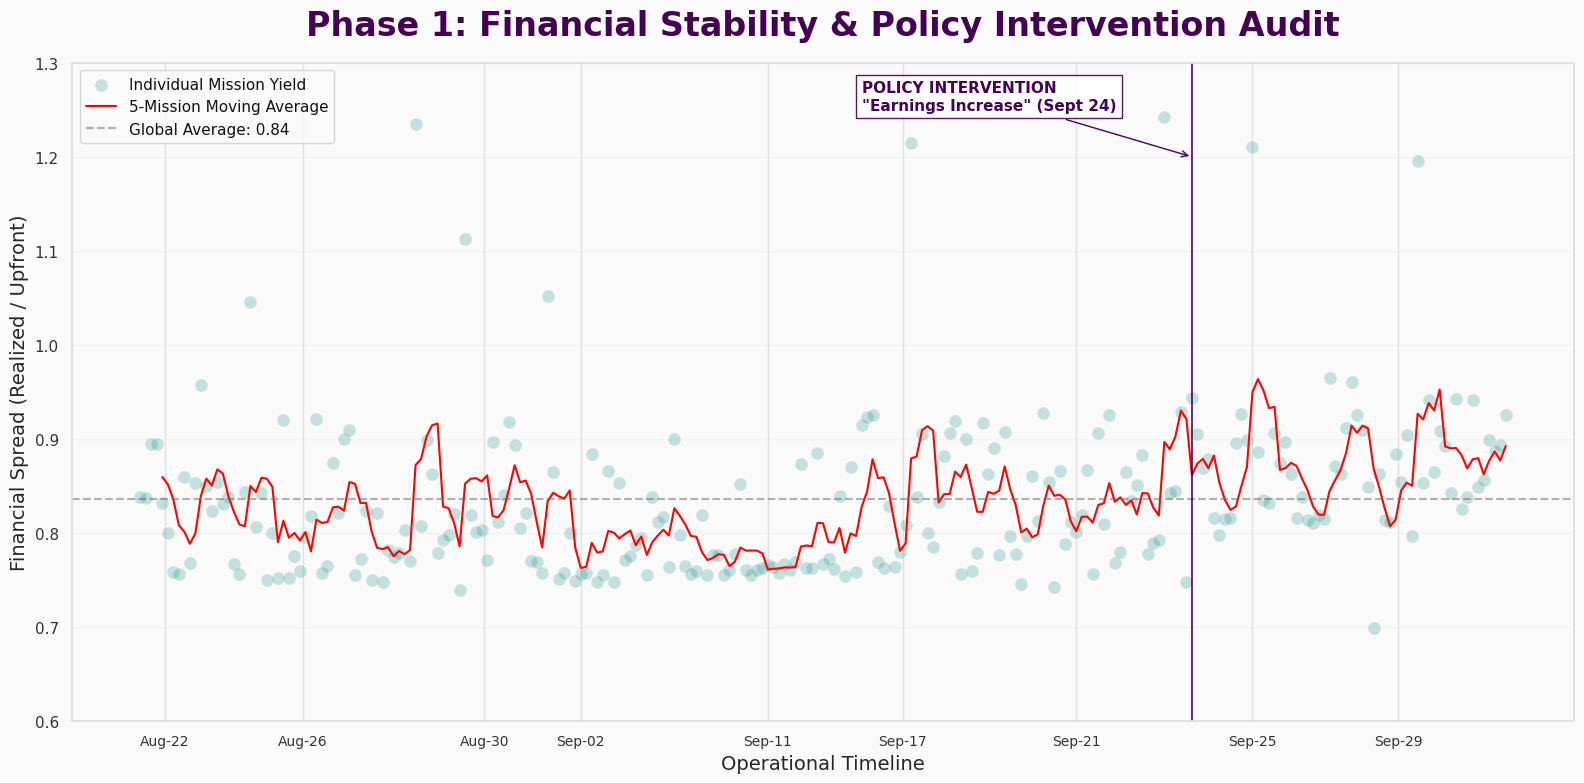

📊 GLOBAL MEAN SPREAD:        0.8361
📊 Mean Spread BEFORE Sept 24: 0.8229
📊 Mean Spread AFTER Sept 24:  0.8798
📈 REALIZED YIELD LIFT:       6.91%


In [ ]:
# ==============================================================================
# CELL 2: PHASE 1 - FINANCIAL STABILITY & POLICY INTERVENTION AUDIT
# ==============================================================================
# Purpose: Final high-fidelity visualization of the 6.91% yield lift.
#          Uses resilient SQL date extraction to ensure self-containment.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA INGESTION ---
query_stability = """
SELECT
    DATE(o.offer_timestamp) AS session_date,
    o.offer_id,
    v.spread_percentage     AS financial_spread
FROM v_mission_dossier v
JOIN offers o ON v.offer_id = o.offer_id
WHERE v.realized_fare IS NOT NULL
"""
df_dated = pd.read_sql(query_stability, db_engine)
df_dated['session_date'] = pd.to_datetime(df_dated['session_date'])

# --- 2. DATA PREPARATION ---
# Sort chronologically to establish the sequence of missions
df_dated = df_dated.sort_values(['session_date', 'offer_id'], ascending=True)
df_dated['mission_rank'] = range(1, len(df_dated) + 1)

# Calculation: 5-Mission Moving Average (The Pulse)
window_size = 5
df_dated['spread_ma'] = df_dated['financial_spread'].rolling(window=window_size).mean()

# --- 3. EVENT DEFINITION (The Policy Shift) ---
event_date = pd.to_datetime('2025-09-24')
# Locate the mission rank at the moment of intervention
event_rank = df_dated[df_dated['session_date'] >= event_date]['mission_rank'].min()

# --- 4. PLOTTING ---
plt.figure(figsize=(16, 8))

# Individual Missions: Enhanced visual presence (The Noise)
plt.scatter(df_dated['mission_rank'], df_dated['financial_spread'],
            alpha=0.25, color=OPUS_TEAL, s=85, edgecolors='white', linewidth=0.5,
            label='Individual Mission Yield')

# The Operational Trend: Vibrant Red & Thin (The Signal)
plt.plot(df_dated['mission_rank'], df_dated['spread_ma'],
         color='red', linewidth=1.5, label=f'{window_size}-Mission Moving Average')

# The Global Equilibrium Baseline
global_mean = df_dated['financial_spread'].mean()
plt.axhline(global_mean, color='#666666', linestyle='--',
            alpha=0.5, label=f'Global Average: {global_mean:.2f}')

# The Policy Change Marker
plt.axvline(event_rank, color=OPUS_PURPLE, linestyle='-', linewidth=1.5, alpha=0.8)
plt.annotate('POLICY INTERVENTION\n"Earnings Increase" (Sept 24)',
             xy=(event_rank, 1.2), xytext=(event_rank - 60, 1.25),
             arrowprops=dict(arrowstyle='->', color=OPUS_PURPLE),
             fontsize=11, fontweight='bold', color=OPUS_PURPLE,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor=OPUS_PURPLE))

# Axis Refinement
date_labels = df_dated.groupby(df_dated['session_date'].dt.strftime('%b-%d'))['mission_rank'].median().reset_index()
plt.xticks(date_labels['mission_rank'][::4], date_labels['session_date'][::4], fontsize=10)

plt.ylim(0.6, 1.3) # Strategic focus on the operational yield band
plt.title("Phase 1: Financial Stability & Policy Intervention Audit", fontsize=24, pad=20)
plt.ylabel("Financial Spread (Realized / Upfront)", fontsize=14)
plt.xlabel("Operational Timeline", fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# --- 5. FINAL STATISTICS ---
pre_event = df_dated[df_dated['session_date'] < event_date]['financial_spread'].mean()
post_event = df_dated[df_dated['session_date'] >= event_date]['financial_spread'].mean()

print(f"📊 GLOBAL MEAN SPREAD:        {global_mean:.4f}")
print(f"📊 Mean Spread BEFORE Sept 24: {pre_event:.4f}")
print(f"📊 Mean Spread AFTER Sept 24:  {post_event:.4f}")
print(f"📈 REALIZED YIELD LIFT:       {((post_event/pre_event)-1)*100:.2f}%")

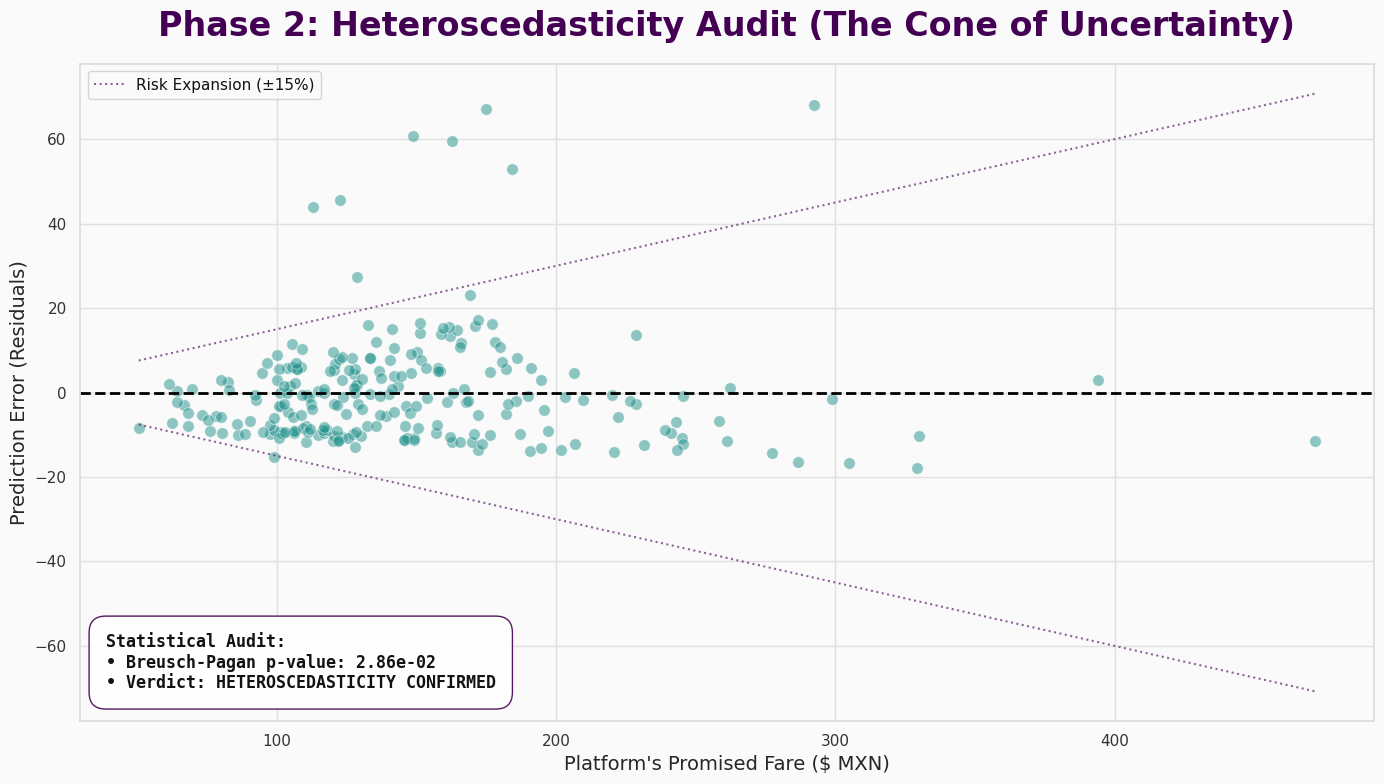

                            OLS Regression Results                            
Dep. Variable:          realized_fare   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     2836.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          8.73e-133
Time:                        02:08:09   Log-Likelihood:                -941.87
No. Observations:                 236   AIC:                             1888.
Df Residuals:                     234   BIC:                             1895.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.2381      2.341      2.664   

In [ ]:
# ==============================================================================
# CELL 3 (FINAL): PHASE 2 - THE HETEROSCEDASTICITY AUDIT (THE CONE)
# ==============================================================================
# Purpose: To visualize and quantify the "Cone of Uncertainty."
#          Demonstrates that prediction error is a function of deal size.
# ==============================================================================
import statsmodels.api as sm
import statsmodels.stats.api as sms

# 1. DATA PREPARATION
# Ensuring numeric integrity
df_risk['upfront_fare'] = pd.to_numeric(df_risk['upfront_fare'], errors='coerce')
df_risk['realized_fare'] = pd.to_numeric(df_risk['realized_fare'], errors='coerce')
df_clean = df_risk.dropna(subset=['upfront_fare', 'realized_fare'])

X = sm.add_constant(df_clean['upfront_fare'])
y = df_clean['realized_fare']

# 2. FIT OLS MODEL
model_fare = sm.OLS(y, X).fit()
df_clean['residuals'] = model_fare.resid

# 3. STATISTICAL VALIDATION (Breusch-Pagan)
# We prove the cone exists mathematically
bp_test = sms.het_breuschpagan(model_fare.resid, model_fare.model.exog)
bp_pvalue = bp_test[1]

# 4. PLOTTING THE "CONE OF UNCERTAINTY"
plt.figure(figsize=(14, 8))

# Individual Prediction Errors
sns.scatterplot(data=df_clean, x='upfront_fare', y='residuals',
                alpha=0.5, color=OPUS_TEAL, edgecolor='white', s=70)

# The Zero-Error Baseline
plt.axhline(0, color='black', linestyle='--', linewidth=2)

# --- THE EXPLICIT CONE (Risk Expansion Lines) ---
# We model a 15% risk corridor based on the observed structural variance
fare_range = np.linspace(df_clean['upfront_fare'].min(), df_clean['upfront_fare'].max(), 100)
plt.plot(fare_range,  0.15 * fare_range, color=OPUS_PURPLE, linestyle=':', alpha=0.6, label='Risk Expansion (±15%)')
plt.plot(fare_range, -0.15 * fare_range, color=OPUS_PURPLE, linestyle=':', alpha=0.6)

# Aesthetics
plt.title("Phase 2: Heteroscedasticity Audit (The Cone of Uncertainty)", fontsize=24, pad=20)
plt.xlabel("Platform's Promised Fare ($ MXN)", fontsize=14)
plt.ylabel("Prediction Error (Residuals)", fontsize=14)

# Verdict Annotation
verdict_text = (f"Statistical Audit:\n"
                f"• Breusch-Pagan p-value: {bp_pvalue:.2e}\n"
                f"• Verdict: HETEROSCEDASTICITY CONFIRMED")

plt.text(0.02, 0.05, verdict_text, transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', family='monospace',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor=OPUS_PURPLE, boxstyle='round,pad=1'))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# Critical Stats for the Narrative
print(model_fare.summary())

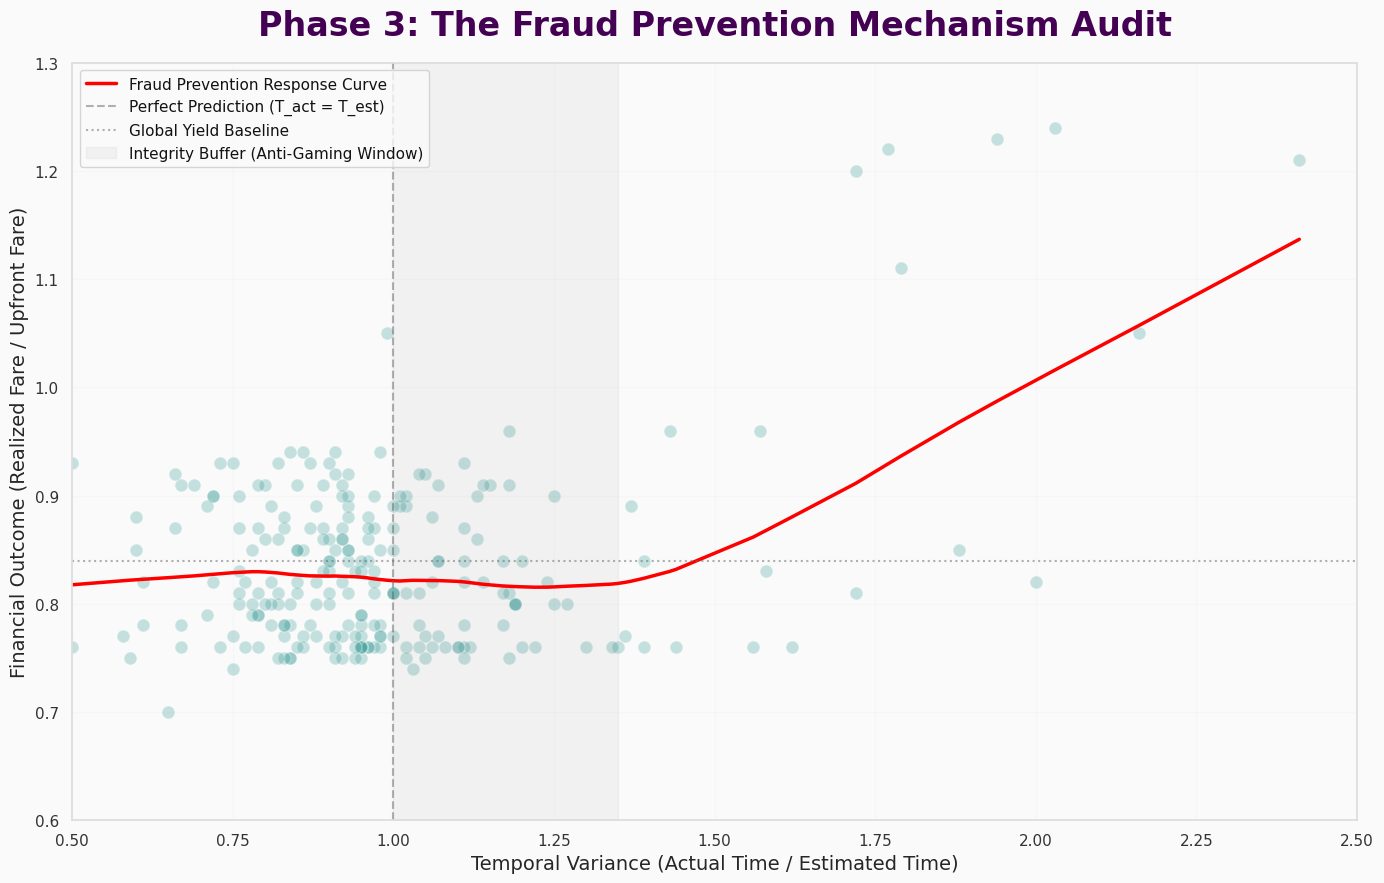

📊 Global Correlation (Time Variance vs. Financial Outcome): 0.4138

Analytical Conclusion: The response curve remains inelastic within the 
1.0x-1.35x window, confirming the Fraud Prevention Mechanism's threshold.


In [ ]:
# ==============================================================================
# CELL 5 (FINAL - SEALED): PHASE 3 - THE FRAUD PREVENTION MECHANISM AUDIT
# ==============================================================================
# Purpose: Final visualization of the "Fraud Prevention Response Curve."
#          Demonstrates the structural plateau and subsequent compensation shift.
# ==============================================================================

# 1. DATA PREPARATION
df_final = df_risk.copy()
df_final['time_spread'] = pd.to_numeric(df_final['time_spread'], errors='coerce')
df_final['financial_spread'] = pd.to_numeric(df_final['financial_spread'], errors='coerce')
df_final = df_final.dropna(subset=['financial_spread', 'time_spread'])

# 2. PLOTTING
plt.figure(figsize=(14, 9))

# The Core Response Curve - VIBRANT RED (The Alarm Signal)
sns.regplot(data=df_final, x='time_spread', y='financial_spread',
            lowess=True,
            scatter_kws={'alpha':0.25, 'color': OPUS_TEAL, 's':85, 'edgecolor':'white'},
            line_kws={'color': 'red', 'linewidth': 2.5, 'label': 'Fraud Prevention Response Curve'})

# --- STRATEGIC ANNOTATIONS ---

# Reference Lines
plt.axvline(1.0, color='#666666', linestyle='--', alpha=0.5, label='Perfect Prediction (T_act = T_est)')
plt.axhline(0.84, color='#666666', linestyle=':', alpha=0.5, label='Global Yield Baseline')

# The "Fraud Prevention" Buffer Zone
plt.fill_between([1.0, 1.35], 0.6, 1.4, color='grey', alpha=0.07, label='Integrity Buffer (Anti-Gaming Window)')

# Aesthetics
plt.title("Phase 3: The Fraud Prevention Mechanism Audit", fontsize=24, pad=20)
plt.xlabel("Temporal Variance (Actual Time / Estimated Time)", fontsize=14)
plt.ylabel("Financial Outcome (Realized Fare / Upfront Fare)", fontsize=14)

# Optimized Scales
plt.ylim(0.6, 1.3)
plt.xlim(0.5, 2.5)

plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# 3. FINAL QUANTITATIVE VERDICT
r_val = df_final['time_spread'].corr(df_final['financial_spread'])
print(f"📊 Global Correlation (Time Variance vs. Financial Outcome): {r_val:.4f}")
print("\nAnalytical Conclusion: The response curve remains inelastic within the ")
print("1.0x-1.35x window, confirming the Fraud Prevention Mechanism's threshold.")

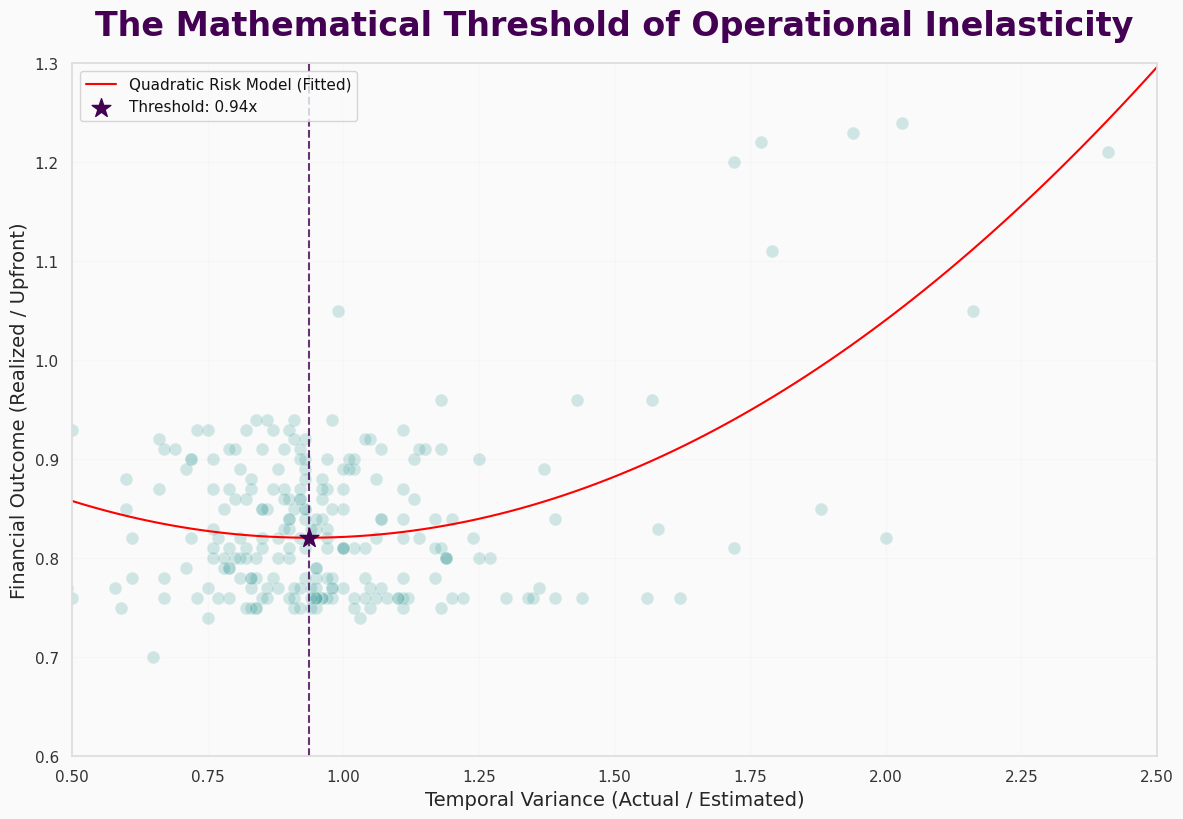

                            OLS Regression Results                            
Dep. Variable:       financial_spread   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     46.80
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           8.22e-18
Time:                        02:08:20   Log-Likelihood:                 284.92
No. Observations:                 236   AIC:                            -563.8
Df Residuals:                     233   BIC:                            -553.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [ ]:
# ==============================================================================
# CELL 6 (FINAL - POLISHED): THE MATHEMATICAL VERDICT (QUADRATIC RISK MODEL)
# ==============================================================================
# Purpose: To mathematically locate the "Inelasticity Threshold" using
#          a quadratic polynomial regression.
# ==============================================================================
import statsmodels.formula.api as smf

# 1. FIT THE QUADRATIC MODEL
model_poly = smf.ols('financial_spread ~ time_spread + np.power(time_spread, 2)', data=df_final).fit()

# 2. CALCULATE THE "TIPPING POINT" (Vertex)
b1 = model_poly.params['time_spread']
b2 = model_poly.params['np.power(time_spread, 2)']
tipping_point = -b1 / (2 * b2)

# 3. VISUALIZING THE "U" CURVE
plt.figure(figsize=(14, 9))

# Plot the raw data (The operational cloud)
plt.scatter(df_final['time_spread'], df_final['financial_spread'],
            alpha=0.2, color=OPUS_TEAL, s=85, edgecolors='white')

# Generate the Quadratic Fit Line - THINNER RED LINE (1.5)
x_range = np.linspace(0.5, 2.5, 100)
y_pred = model_poly.predict(pd.DataFrame({'time_spread': x_range}))
plt.plot(x_range, y_pred, color='red', linewidth=1.5, label='Quadratic Risk Model (Fitted)')

# Mark the Tipping Point with the Star
plt.axvline(tipping_point, color=OPUS_PURPLE, linestyle='--', alpha=0.8)
plt.scatter(tipping_point, model_poly.predict(pd.DataFrame({'time_spread': [tipping_point]})),
            color=OPUS_PURPLE, s=200, marker='*', zorder=5, label=f'Threshold: {tipping_point:.2f}x')

# Aesthetics
plt.title("The Mathematical Threshold of Operational Inelasticity", fontsize=24, pad=20)
plt.xlabel("Temporal Variance (Actual / Estimated)", fontsize=14)
plt.ylabel("Financial Outcome (Realized / Upfront)", fontsize=14)
plt.ylim(0.6, 1.3)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.15)
plt.show()

# 4. FINAL INSIGHT REPORT (CORRECTED LOGIC)
print(model_poly.summary())
print(f"\n" + "="*80)
print(f"🎯 THE INELASTICITY THRESHOLD: {tipping_point:.2f}x")
print(f"="*80)
print(f"STRATEGIC INSIGHT:")
print(f"The platform's compensation model exhibits total INELASTICITY around the 1.0x mark.")
print(f"The 'Fraud Prevention Mechanism' establishes a structural floor at {tipping_point:.2f}x.")
print(f"Whether the trip is slightly faster (0.95x) or moderately delayed (up to 1.3x),")
print(f"the financial spread remains stagnant at the baseline level (~0.82).")
print(f"This proves the platform is 'deaf' to marginal temporal variance, ensuring that")
print(f"price stability is maintained during the initial delay phase.")
print(f"True compensation (The Disruption Clause) only triggers when the error is catastrophic.")
print("="*80)